<a href="https://colab.research.google.com/github/agbizbuz/learning-ai-ds-ml/blob/main/simplilearn_ml_python/birch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
# BIRCH Clustering
## Balanced Iterative Reducing and Clustering using Hierarchies

BIRCH is a scalable clustering algorithm that builds a **Cluster Feature Tree (CF-Tree)** to summarize data incrementally. It is particularly efficient for large datasets because it
- Processes data in a single pass (incremental),
- Produces both subclusters and a global clustering,
- Uses a space hierarchy to compactly summarize cluster information.

**Key Parameters:**
| Parameter | Description |
|---|---|
| `branching_factor` | Max subclusters per CF-Tree node |
| `threshold` | Distance threshold for adding points to existing subcluster |
| `n_clusters` | Final number of clusters (if `None`, uses only CF-Tree leaves) |
| `compute_labels` | Whether to compute labels during fit |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 7)

# Data generation
from sklearn.datasets import make_blobs

# BIRCH model
from sklearn.cluster import Birch

# Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Visualization helpers
from matplotlib.colors import ListedColormap

## 1. Generate Sample Clustered Data

We will use `sklearn.datasets.make_blobs` to generate well-separated clusters.
This helps us visually verify if BIRCH recovers the true structure.

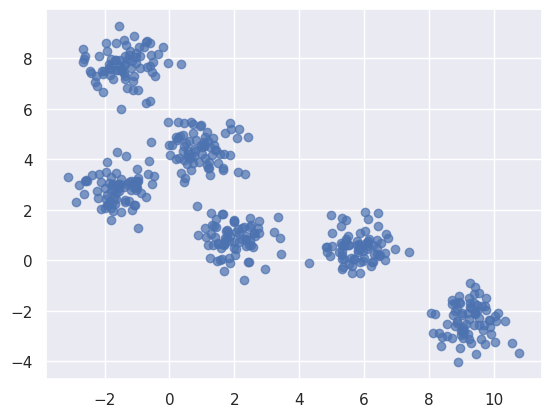

In [2]:
# Generate synthetic dataset with known cluster structure
X, true_labels = make_blobs(
    n_samples=450,
    centers=6,
    cluster_std=0.6,
    random_state=0
)
# Dataset summary
print(f"Dataset shape: {X.shape}")
print(f"Number of true clusters: {len(np.unique(true_labels))}")
for l in np.unique(true_labels):
    count = np.sum(true_labels == l)
    print(f"  Cluster {l}: {count} samples")

In [ ]:
# Visualize the raw data (true labels)
fig, ax = plt.subplots(figsize=(9, 7))
cm = plt.cm.get_cmap('tab10', len(np.unique(true_labels)))

for label in np.unique(true_labels):
    mask = true_labels == label
    ax.scatter(X[mask, 0], X[mask, 1],
               label=f'Cluster {label}', c=[cm(label)],
               edgecolors='k', s=80, alpha=0.85)

ax.set_title('Raw Data: True Cluster Assignments', fontsize=16, fontweight='bold')
ax.set_xlabel('Feature 0', fontsize=12)
ax.set_ylabel('Feature 1', fontsize=12)
ax.legend(title='True Clusters', fontsize=10)
plt.tight_layout()
plt.show()

## 2. BIRCH Model: Understanding the CF-Tree

BIRCH builds a **Cluster Feature (CF) Tree** with three levels of nodes:

| Node Type       | Role                                                    |
|-----------------|--------------------------------------------------------|
| **Leaf nodes**  | Store subcluster summaries (n, linear sum, sum of sq.) |
| **Non-leaf**    | Route entries to children; store subtree CFs           |
| **Root**        | Entry point; stores CFs of all children subtrees       |

**How it works:**
1. Each data point is inserted into the CF-Tree incrementally
2. If the point is within the *threshold* distance of a leaf's subcluster → absorb it
3. Otherwise → create a new subcluster (if leaf has room; up to `branching_factor`)
4. If the leaf is full → *split* the leaf into two new leaf nodes
5. Finally, if `n_clusters` is set, a secondary global clustering step merges subclusters

In [ ]:
# ─── Fit BIRCH ───
brc = Birch(
    branching_factor=50,   # max subclusters per CF-Tree node
    n_clusters=6,          # final clusters (None = use only CF-Tree leaves)
    threshold=1.5,         # distance cutoff for absorbing a point into a subcluster
    compute_labels=True,   # compute labels during fit (saves a predict() call later)
)
brc.fit(X)

# ─── Inspect the CF-Tree ───
print(f"CF-Tree root type : {type(brc.root).__name__}")
print(f"CF-Tree leaf type  : {type(brc.leaf).__name__}")
print(f"Number of subclusters in CF-Tree leaves : {len(brc.subcluster_centers_)}")
print(f"Final number of clusters                : {len(np.unique(brc.labels_))}")
print(f"Subcluster centers shape                : {brc.subcluster_centers_.shape}")

In [ ]:
# Predict cluster labels
labels = brc.predict(X)

# Verify fit/predict give the same result
assert (labels == brc.labels_).all(), 'labels mismatch!'

# Label distribution
unique, counts = np.unique(labels, return_counts=True)
print('--- Cluster Distribution ---')
for lbl, cnt in zip(unique, counts):
    pct = cnt / len(labels) * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  Cluster {lbl:>2}: {cnt:>4}  ({pct:5.1f}%)  {bar}')

n = len(labels)
k = len(unique)
print(f'Total samples: {n}')
print(f'Number of predicted clusters: {k}')

In [ ]:
# Side-by-side: True vs BIRCH vs Subcluster centers
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
cm = plt.cm.get_cmap('tab10', 10)

# Plot 1 -- True labels
for label in np.unique(true_labels):
    mask = true_labels == label
    axes[0].scatter(X[mask, 0], X[mask, 1],
                   c=[cm(label)], edgecolors='k', s=80, alpha=0.85,
                   label=f'True {label}')
axes[0].set_title('True Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')
axes[0].legend(fontsize=8)

# Plot 2 -- BIRCH predicted labels
for label in np.unique(labels):
    mask = labels == label
    axes[1].scatter(X[mask, 0], X[mask, 1],
                   c=[cm(int(label) % 10)], edgecolors='k', s=80,
                   alpha=0.85, label=f'BIRCH {label}')
axes[1].set_title('BIRCH Predicted Clusters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Feature 1')
axes[1].legend(fontsize=8)

# Plot 3 -- Subcluster centers overlaid
scatter = axes[2].scatter(X[:, 0], X[:, 1], c=labels,
                          cmap='tab10', s=50, alpha=0.6, edgecolors='none')
subcenters = brc.subcluster_centers_
axes[2].scatter(subcenters[:, 0], subcenters[:, 1],
               c='red', marker='X', s=200, edgecolors='darkred',
               linewidths=2, label='CF-Tree subcluster centers')
centroids = [X[labels == l].mean(axis=0) for l in np.unique(labels)]
axes[2].scatter([c[0] for c in centroids], [c[1] for c in centroids],
               c='green', marker='*', s=350, edgecolors='darkgreen',
               linewidths=2, label='Final cluster centroids')
axes[2].set_title('Subcluster Centers (X) + Final Centroids (*)',
                   fontsize=14, fontweight='bold')
axes[2].set_xlabel('Feature 0')
axes[2].set_ylabel('Feature 1')
axes[2].legend(fontsize=9)

fig.suptitle('BIRCH Clustering Results', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Evaluate Clustering Quality

Since BIRCH is unsupervised, we use internal validation metrics.
We can also compare with the ground truth when available.

In [ ]:
# Internal clustering metrics (higher Silhouette & CH = better; lower DB = better)
sil = silhouette_score(X, labels)
ch  = calinski_harabasz_score(X, labels)
db  = davies_bouldin_score(X, labels)

print('--- Internal Metrics (BIRCH) ---')
print(f'  Silhouette Score       : {sil:.4f}')
print(f'  Calinski-Harabasz Index : {ch:.2f}')
print(f'  Davies-Bouldin Index    : {db:.4f}')

# Compare with true labels for the same metrics
sil_true = silhouette_score(X, true_labels)
ch_true  = calinski_harabasz_score(X, true_labels)
db_true  = davies_bouldin_score(X, true_labels)

print()
print('--- Internal Metrics (True Labels) ---')
print(f'  Silhouette Score       : {sil_true:.4f}')
print(f'  Calinski-Harabasz Index : {ch_true:.2f}')
print(f'  Davies-Bouldin Index    : {db_true:.4f}')

# Summary comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_names = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
birch_vals    = [sil, ch, db]
true_vals     = [sil_true, ch_true, db_true]
colors_birch  = '#2196F3'
colors_true   = '#4CAF50'

for idx, (ax, name) in enumerate(zip(axes, metrics_names)):
    vals = [birch_vals[idx], true_vals[idx]]
    bars = ax.bar(['BIRCH', 'True'], vals, color=[colors_birch, colors_true])
    ax.set_title(name, fontsize=13, fontweight='bold')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(h*0.01, 0.5),
                f'{h:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis: Effect of `threshold` & `n_clusters`

The `threshold` controls the radius of subclusters in the CF-Tree.
A small threshold creates many fine-grained subclusters; a large one merges them aggressively.
Let's sweep the threshold and observe how the Silhouette score changes.

In [ ]:
# Sweep threshold values
thresholds = [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
results = []

for t in thresholds:
    model = Birch(branching_factor=50, n_clusters=6, threshold=t,
                  compute_labels=True)
    model.fit(X)
    n_clusters_found = len(np.unique(model.labels_))
    n_subclusters = len(model.subcluster_centers_)
    sil = silhouette_score(X, model.labels_)
    results.append({
        'threshold': t,
        'n_clusters': n_clusters_found,
        'n_subclusters': n_subclusters,
        'silhouette': sil
    })

# Summary table
import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False))

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

x = df['threshold'].values
line1, = ax1.plot(x, df['silhouette'], 'b-o', linewidth=2,
                   markersize=8, label='Silhouette Score')
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Silhouette Score', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
line2, = ax2.plot(x, df['n_subclusters'], 'r-s', linewidth=2,
                   markersize=8, label='CF-Tree Subclusters')
ax2.set_ylabel('Number of Subclusters', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_title('Silhouette Score & Subclusters vs Threshold',
              fontsize=15, fontweight='bold')

# Combine legends
lines = [line1, line2]
labs = [l.get_label() for l in lines]
ax1.legend(lines, labs, loc='best', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Why BIRCH? Scalability Demonstration

BIRCH excels when dealing with very large datasets because:
- It processes data **in a single pass**, using O(1) memory per subcluster
- The CF-Tree compactly summarizes the data
- It supports **incremental learning** via `partial_fit()`

Let's benchmark BIRCH on a larger dataset.

In [ ]:
import time
from sklearn.cluster import KMeans

# Large dataset
X_large, true_large = make_blobs(
    n_samples=20000, centers=8, cluster_std=1.0, random_state=42
)
print(f'Large dataset: {X_large.shape[0]} samples, 8 true clusters')
print()

# Benchmark BIRCH
t0 = time.time()
brc_large = Birch(branching_factor=50, n_clusters=8, threshold=1.5)
brc_large.fit(X_large)
birch_time = time.time() - t0
sil_large = silhouette_score(X_large, brc_large.labels_)

# Benchmark KMeans for comparison
t0 = time.time()
km = KMeans(n_clusters=8, random_state=42, n_init="auto")
km.fit_predict(X_large)
km_time = time.time() - t0
sil_km = silhouette_score(X_large, km.labels_)

# Results table
from io import StringIO
io = StringIO()
io.write('+-----------+--------+------------+\n')
io.write('| Algorithm | Time(s) | Silhouette |\n')
io.write('+-----------+--------+------------+\n')
io.write(f'| BIRCH     | {birch_time:.3f}    | {sil_large:.4f}       |\n')
io.write(f'| KMeans    | {km_time:.3f}    | {sil_km:.4f}       |\n')
io.write('+-----------+--------+------------+\n')
print(io.getvalue())

# Plot the large clustering result (thin points for performance)
plt.figure(figsize=(10, 8))
pl = plt.scatter(X_large[:, 0], X_large[:, 1],
                 c=brc_large.labels_, cmap='tab10',
                 s=3, alpha=0.5)
centers = [X_large[brc_large.labels_ == l].mean(axis=0)
           for l in range(8)]
plt.scatter([c[0] for c in centers], [c[1] for c in centers],
           c='red', marker='*', s=400, edgecolors='k', linewidths=2,
           label='Centroids')
plt.title(f'BIRCH on 20,000 samples (8 clusters, {birch_time:.2f}s)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature 0', fontsize=12)
plt.ylabel('Feature 1', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Details |
|---|--|
| **Algorithm** | BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies) |
| **Data Structure** | CF-Tree (Cluster Feature Tree) |
| **Best Use Case** | Large datasets, streaming data, when memory is a constraint |
| **Strengths** | Single-pass, incremental learning, produces hierarchical clusters |
| **Weaknesses** | Sensitive to `threshold` & `branching_factor`; struggles with non-spherical clusters |

---
*Built with `scikit-learn` for educational purposes.*